## Importing Dataset

In [358]:
import pandas as pd

In [359]:
data = pd.read_csv("loan_prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [360]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

## Now we will discuss the problem statement

**Overview**

* The goal of this project is to develop a predictive model that can accurately determine whether a loan application will be approved based on the applicant's profile. This prediction model can be invaluable for financial institutions, helping them to assess the risk associated with lending to different applicants more efficiently.

**Business Problem**  

* Loan approval is a critical decision-making process for financial institutions. Approving loans to applicants with a high probability of default can lead to significant financial losses. On the other hand, rejecting applicants who are likely to repay can lead to lost business opportunities. Therefore, the ability to predict loan approval outcomes based on an applicant's profile can help optimize lending processes, reduce financial risk, and improve customer satisfaction by speeding up the decision-making process.

**Dataset Description**

* The dataset contains information on applicants who have applied for loans. Each applicant's profile includes various features that are used by financial institutions to evaluate the likelihood of loan approval. The dataset consists of the following variables:

**Independent Variables (Features)**

Loan_ID: A unique identifier for each loan application.

Gender: The gender of the applicant (Male/Female).

Married: Marital status of the applicant (Yes/No).

Dependents: Number of dependents the applicant has.

Education: Education level of the applicant (Graduate/Not Graduate).

Self_Employed: Whether the applicant is self-employed (Yes/No).

ApplicantIncome: The income of the applicant.

CoapplicantIncome: The income of the co-applicant.

Loan_Amount: The amount of loan applied for.

Loan_Amount_Term: The term of the loan in months.

Credit_History: Credit history of the applicant (1 = good, 0 = bad).

Property_Area: The area in which the property is located (Urban/Semiurban/Rural).

**Dependent Variable (Target Variable)**

Loan_Status: The status of the loan application (Y = approved, N = not approved).



## EDA (Exploratory Data Analysis)

In [361]:
# Detecting rows and columns

data.shape

(614, 13)

In [362]:
# Detecting total number of elements in the dataset

data.size

7982

In [363]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [364]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [365]:
# Detecting Dimension of the dataset

data.ndim

2

In [366]:
# Detecting Datatypes of the variables

data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

* We can observe that the "Dependents" has continuous data in the dataset but it is saved as object type in dataset. So, we will handle this.

In [367]:
# Detecting null values

data.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

* We can observe that some column contains Null values in the dataset. So, we will handle this.

In [368]:
# Detecting Duplicacy

data.duplicated().sum()

0

In [369]:
# Detecting Cardinality of variables

data.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

* Cardinality gives number of unique records.

Categorical Variable -> Cardinality will low

Continuous Variable -> Cardinality will high

In [370]:
# Detecting any kind of inaccuracies and faults

data.head(60)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


* We can clearly see through dataset that column 'Dependents' has unnecessary '+' sign and some float datatype columns has no decimal values. So, we will handle this.

## Data pre-processing/Data cleaning/Data munging/Data wrangling

In [371]:
# Droping unnecessary columns

data.drop(columns = 'Loan_ID', inplace = True)

In [372]:
# Handling inaccuracies and faults in the dataset

data.Dependents.value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [373]:
# We will remove this "+" sign

data.Dependents = data.Dependents.str.replace("+","")

* Handling Null Values :- We can not drop null values because our dataset is very small in size so, we will fill those null values

In [374]:
# Filling missing values for categorical columns

data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Married'].fillna(data['Married'].mode()[0], inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace=True)

In [375]:
# Filling missing values for numerical columns
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0], inplace=True)

In [376]:
data.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [377]:
# Handling Datatype problem in the dataset

data.Dependents        = data.Dependents.astype('int64')
data.CoapplicantIncome = data.CoapplicantIncome.astype('int64')
data.LoanAmount        = data.LoanAmount.astype('int64')
data.Loan_Amount_Term  = data.Loan_Amount_Term.astype('int64')
data.Credit_History    = data.Credit_History.astype('int64')

In [378]:
data.dtypes

Gender               object
Married              object
Dependents            int64
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount            int64
Loan_Amount_Term      int64
Credit_History        int64
Property_Area        object
Loan_Status          object
dtype: object

In [379]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

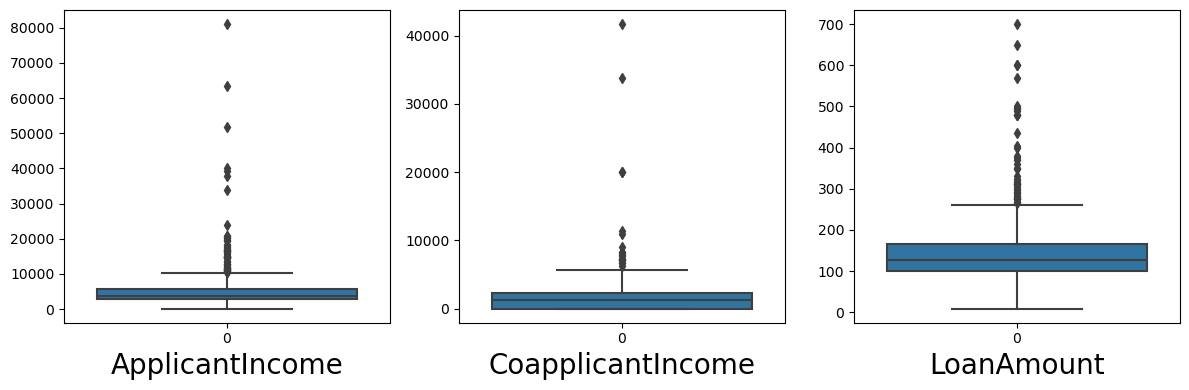

In [380]:
# Outliers Detection using Boxplot

continous_variable = data[["ApplicantIncome","CoapplicantIncome","LoanAmount"]]

plt.figure(figsize=(12,4),facecolor='w')
plotnumber=1
for i in continous_variable:
    if plotnumber <=3:
        plt.subplot(1,3,plotnumber)
        ax=sns.boxplot(data=data[i])
        plt.xlabel(i,fontsize=20)
    plotnumber +=1
plt.tight_layout()

* Outliers are present but we are not going to remove these outliers because we have bank loan dataset in which each record is very crucial and second thing that we have very small dataset.

In [381]:
#  Data Distribution of the target variable

data.Loan_Status.value_counts()  

Loan_Status
Y    422
N    192
Name: count, dtype: int64

* Dataset is Imbalanced and we are not going to balance it because out size of dataset is very small due to this it will impact our model 

# Visualization

Gender
Male      502
Female    112
Name: count, dtype: int64


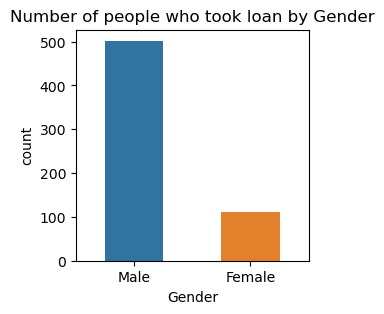

In [382]:
print(data.Gender.value_counts())

plt.figure(figsize = (3,3))
plt.title("Number of people who took loan by Gender")
sns.countplot(x = data.Gender, width=0.5)
plt.show()

Married
Yes    401
No     213
Name: count, dtype: int64


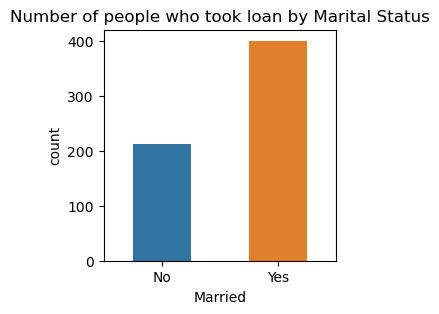

In [383]:
print(data.Married.value_counts())

plt.figure(figsize = (3,3))
plt.title("Number of people who took loan by Marital Status")
sns.countplot(x = data.Married, width=0.5)
plt.show()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


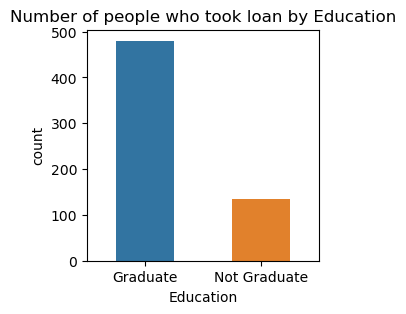

In [384]:
print(data.Education.value_counts())

plt.figure(figsize = (3,3))
plt.title("Number of people who took loan by Education")
sns.countplot(x = data.Education, width=0.5)
plt.show()

* Checking Co-Relation between variables

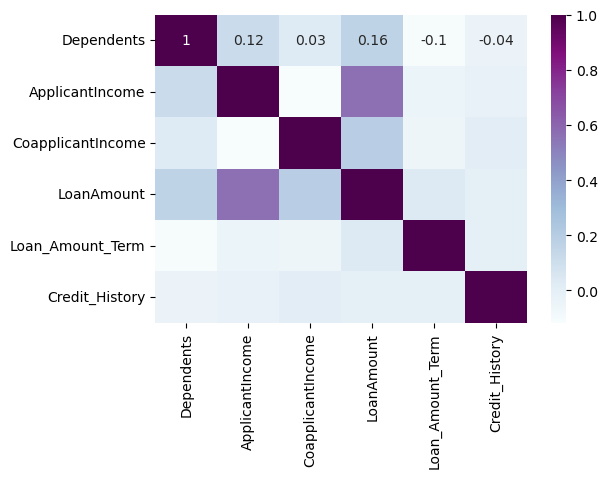

In [385]:
corr = data.select_dtypes(include = "number").corr()
plt.figure(figsize = (6,4))
sns.heatmap(corr, annot = True, cmap = "BuPu")
plt.show()

In [386]:
corr

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Dependents,1.000000,0.118202,0.030429,0.163103,-0.103864,-0.040160
ApplicantIncome,0.118202,1.000000,-0.116604,0.565181,-0.046531,-0.018615
CoapplicantIncome,0.030429,-0.116604,1.000000,0.189218,-0.059382,0.011134
LoanAmount,0.163103,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.103864,-0.046531,-0.059382,0.036960,1.000000,-0.004705
Credit_History,-0.040160,-0.018615,0.011134,-0.000607,-0.004705,1.000000


* Checking Data distribution of the continuous variable

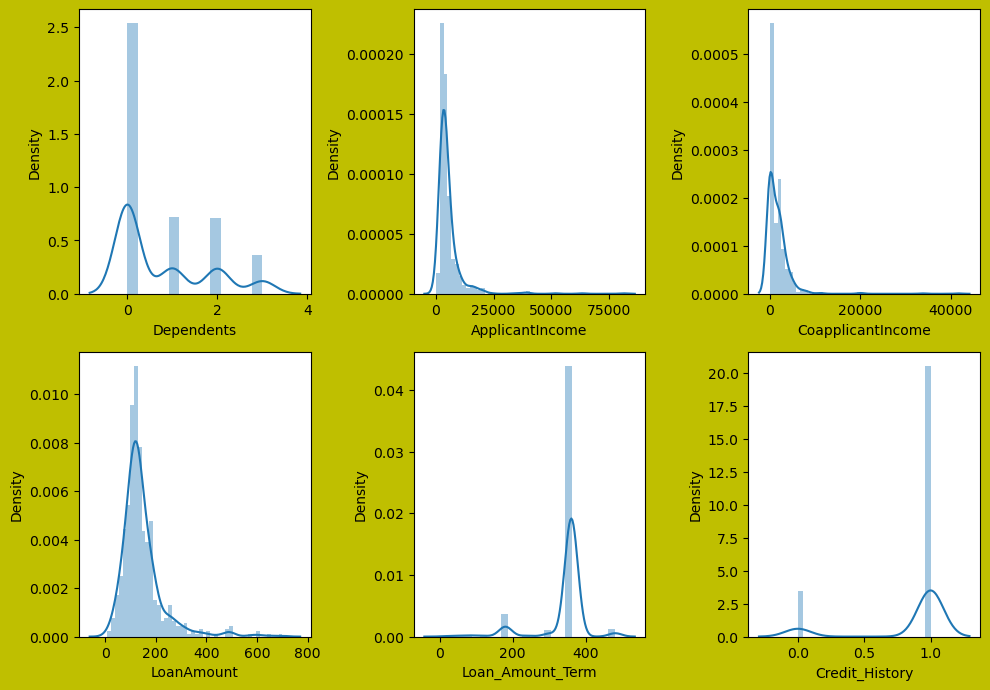

In [387]:
plt.figure(figsize=(10,10),facecolor='y')
graph=1
for i in data.select_dtypes(include = "number"):
    if graph <=6:
        ax=plt.subplot(3,3,graph)
        sns.distplot(data[i])
        plt.xlabel(i)
    graph +=1
plt.tight_layout()

## Encoding - Converting categorical variables into numerical format using methods like one-hot encoding or label encoding or by manual.

* Here we can see that there are two Income columns like Appplicant and CoApplicant Income. Hence CoApplicant Income has many 0 values so it will not impact so much on the model so we just add those two columns

In [388]:
## Total Applicant Income

data["Total_Income"] = data.ApplicantIncome + data.CoapplicantIncome

In [389]:
## Dropping Unnecessary columns

data.drop(columns={"ApplicantIncome","CoapplicantIncome"}, inplace = True)

In [390]:
from sklearn.preprocessing import LabelEncoder

In [391]:
cols = ["Gender","Married","Education","Self_Employed","Property_Area","Loan_Status"]
LE = LabelEncoder()
for i in cols:
    data[i] = LE.fit_transform(data[i])

In [392]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,1,0,0,0,0,128,360,1,2,1,5849
1,1,1,1,0,0,128,360,1,0,0,6091
2,1,1,0,0,1,66,360,1,2,1,3000
3,1,1,0,1,0,120,360,1,2,1,4941
4,1,0,0,0,0,141,360,1,2,1,6000


## Dividing dataset into Features and Labels

In [393]:
X = data.drop(columns="Loan_Status")
y = data[["Loan_Status"]]

## Normalizing the data

In [394]:
from sklearn.preprocessing import StandardScaler

In [395]:
scaler = StandardScaler()
scaler

StandardScaler()

In [396]:
X_scaled = scaler.fit_transform(X)

## Checking Multi-Collinearity by using VIF (Variance Inflation Factor)

In [397]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [398]:
vif = pd.DataFrame()
vif['Vif']=[variance_inflation_factor(X_scaled,i) for i in range (X_scaled.shape[1])]

vif['Features']=X.columns

In [399]:
vif

,Vif,Features
0,1.167887,Gender
1,1.279288,Married
2,1.164130,Dependents
3,1.063123,Education
4,1.020517,Self_Employed
5,1.709754,LoanAmount
6,1.047996,Loan_Amount_Term
7,1.008269,Credit_History
8,1.016181,Property_Area
9,1.670692,Total_Income


* All the VIF are less then 5 and are very low, That means no multicollinearity is present.Now, we can go ahead with fitting our data to the model. Before that lets split our data in Train and Test.

In [400]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score , confusion_matrix 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

## Now train, test and split the data

In [401]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled, y, test_size = 0.25, random_state = 51)

# Model Selection

In [402]:
## Logistic Regression

LR = LogisticRegression()
LR.fit(X_train,y_train)
y_pred_1 = LR.predict(X_test)
Accuracy = accuracy_score(y_test,y_pred_1)

In [403]:
Accuracy*100

84.4155844155844

* Checking Cross Validation

In [404]:
score = cross_val_score(LR, X, y, cv = 5 )
score

array([0.81300813, 0.76422764, 0.7804878 , 0.85365854, 0.80327869])

In [405]:
import numpy as np

np.mean(score)*100

80.29321604691455

In [406]:
## Decision Tree Classifier

DTC = DecisionTreeClassifier()
DTC.fit(X_train,y_train)
y_pred_2 = DTC.predict(X_test)
Accuracy = accuracy_score(y_test,y_pred_2)

In [407]:
Accuracy*100

72.72727272727273

* Checking Cross Validation

In [408]:
score = cross_val_score(DTC, X, y, cv = 5 )
score

array([0.65853659, 0.69918699, 0.67479675, 0.70731707, 0.69672131])

In [409]:
np.mean(score)*100

68.7311741969879

In [410]:
## Random Forest Classifier

RFC = RandomForestClassifier()
RFC.fit(X_train,y_train)
y_pred_3 = RFC.predict(X_test)
Accuracy = accuracy_score(y_test,y_pred_3)

In [411]:
Accuracy*100

82.46753246753246

* Checking Cross Validation

In [412]:
score = cross_val_score(RFC, X, y, cv = 5 )
score

array([0.76422764, 0.72357724, 0.76422764, 0.84552846, 0.81147541])

In [413]:
np.mean(score)*100

78.18072770891644

In [414]:
## KNeighborsClassifier

KNC = KNeighborsClassifier(n_neighbors = 3)
KNC.fit(X_train,y_train)
y_pred_4 = KNC.predict(X_test)
Accuracy = accuracy_score(y_test,y_pred_4)

In [415]:
Accuracy*100

79.22077922077922

* Checking Cross Validation

In [416]:
score = cross_val_score(KNC, X, y, cv = 5 )
score

array([0.61788618, 0.55284553, 0.58536585, 0.57723577, 0.59016393])

In [417]:
np.mean(score)*100

58.469945355191264

## Some Metrices for Model Evaluation

In [418]:
def classification_reports(model_name, y_test, y_pred):
    report = classification_report(y_test, y_pred)
    print(f"Classification Report for {model_name}:\n{report}\n")
    return

In [419]:
classification_reports(LR, y_test, y_pred_1)
classification_reports(DTC, y_test, y_pred_2)
classification_reports(RFC, y_test, y_pred_3)
classification_reports(KNC, y_test, y_pred_4)

Classification Report for LogisticRegression():
              precision    recall  f1-score   support

           0       1.00      0.44      0.61        43
           1       0.82      1.00      0.90       111

    accuracy                           0.84       154
   macro avg       0.91      0.72      0.76       154
weighted avg       0.87      0.84      0.82       154


Classification Report for DecisionTreeClassifier():
              precision    recall  f1-score   support

           0       0.51      0.58      0.54        43
           1       0.83      0.78      0.81       111

    accuracy                           0.73       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.74      0.73      0.73       154


Classification Report for RandomForestClassifier():
              precision    recall  f1-score   support

           0       0.81      0.49      0.61        43
           1       0.83      0.95      0.89       111

    accuracy                

# Hyper Parameter Tuning

In [420]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [421]:
## Logistic Regression

log_reg_grid={"C":np.logspace(-4,4,20),
             "solver":['liblinear']}

rs_log_reg=RandomizedSearchCV(LogisticRegression(),
                   param_distributions=log_reg_grid,
                  n_iter=20,cv=5,verbose=1)

rs_log_reg.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=1)

In [422]:
rs_log_reg.best_score_

0.7978260869565218

In [423]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 0.0018329807108324356}

In [424]:
## Random Forest Classifier

rf_grid={'n_estimators':np.arange(10,1000,10),
  'max_features':['auto','sqrt'],
 'max_depth':[None,3,5,10,20,30],
 'min_samples_split':[2,5,20,50,100],
 'min_samples_leaf':[1,2,5,10]
 }

rs_rf=RandomizedSearchCV(RandomForestClassifier(),
                  param_distributions=rf_grid,
                   cv=5,
                   n_iter=20,
                  verbose=True)

rs_rf.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10, 20, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 20, 50,
                                                              100],
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260,
       270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390,
       400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520,
       530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650,
       660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780,
       790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910,
       920, 930, 940, 950, 960, 970, 980, 990])},
                   verbose=True)

In [425]:
rs_rf.best_score_

0.8043478260869567

In [426]:
rs_rf.best_params_

{'n_estimators': 260,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [427]:
## Decision Tree Classifier

dt_model = DecisionTreeClassifier()

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_dt.fit(X_train, y_train)

# Best parameters
print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best score for Decision Tree: {grid_search_dt.best_score_}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'random'}
Best score for Decision Tree: 0.7652173913043478


In [428]:
## K Neighbors Classifier

knC_model = KNeighborsClassifier()

# Define the parameter grid
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Perform Grid Search
grid_search_knn = GridSearchCV(estimator=knC_model, param_grid=param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_knn.fit(X_train, y_train)

# Best parameters
print(f"Best parameters for KNC: {grid_search_knn.best_params_}")
print(f"Best score for KNC: {grid_search_knn.best_score_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for KNC: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best score for KNC: 0.7978260869565217


# Retraining models with best parameters

In [429]:
## Logistic Regression

lr1 = LogisticRegression(C= 0.0018329807108324356, solver = 'liblinear')
lr1.fit(X_train, y_train)

X_train_pred_lr1 = lr1.predict(X_train)
training_data_acc_lr1 = accuracy_score(X_train_pred_lr1,y_train)

X_test_pred_lr1 = lr1.predict(X_test)
test_data_acc_lr1 = accuracy_score(X_test_pred_lr1,y_test)

print('Classification_Report: ',classification_report(y_test, X_test_pred_lr1))
print('Confusion_matrix: ',confusion_matrix(y_test, X_test_pred_lr1))
print('Accuracy: ',test_data_acc_lr1)

Classification_Report:                precision    recall  f1-score   support

           0       1.00      0.44      0.61        43
           1       0.82      1.00      0.90       111

    accuracy                           0.84       154
   macro avg       0.91      0.72      0.76       154
weighted avg       0.87      0.84      0.82       154

Confusion_matrix:  [[ 19  24]
 [  0 111]]
Accuracy:  0.8441558441558441


In [430]:
## Random Forest Classifier

rf1 = RandomForestClassifier(max_depth = 5, min_samples_leaf = 10, min_samples_split = 5, n_estimators = 200)
rf1.fit(X_train, y_train)

X_train_pred_rf1 = rf1.predict(X_train)
tarining_data_acc_rf1 = accuracy_score(X_train_pred_rf1,y_train)

X_test_pred_rf1 = rf1.predict(X_test)
test_data_acc_rf1 = accuracy_score(X_test_pred_rf1,y_test)

print('classification_report: ',classification_report(y_test, X_test_pred_rf1))
print('confusion_matrix: ',confusion_matrix(y_test, X_test_pred_rf1))
print('Accuracy: ',test_data_acc_rf1)

classification_report:                precision    recall  f1-score   support

           0       1.00      0.44      0.61        43
           1       0.82      1.00      0.90       111

    accuracy                           0.84       154
   macro avg       0.91      0.72      0.76       154
weighted avg       0.87      0.84      0.82       154

confusion_matrix:  [[ 19  24]
 [  0 111]]
Accuracy:  0.8441558441558441


In [431]:
## Decision Tree Classifier

dt1 = DecisionTreeClassifier(criterion = 'gini', max_depth = None, min_samples_leaf = 4, min_samples_split = 2, splitter = 'random')
dt1.fit(X_train,y_train)

X_train_pred_dt1 = dt1.predict(X_train)
training_data_acc_dt1 = accuracy_score(X_train_pred_dt1,y_train)

X_test_pred_dt1 = dt1.predict(X_test)
test_data_acc_dt1 = accuracy_score(X_test_pred_dt1,y_test)

print('Classification_Report: ',classification_report(y_test, X_test_pred_dt1))
print('Confusion_matrix: ',confusion_matrix(y_test, X_test_pred_dt1))
print('Accuracy: ',test_data_acc_dt1)

Classification_Report:                precision    recall  f1-score   support

           0       0.61      0.53      0.57        43
           1       0.83      0.86      0.85       111

    accuracy                           0.77       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.77      0.77      0.77       154

Confusion_matrix:  [[23 20]
 [15 96]]
Accuracy:  0.7727272727272727


In [432]:
## K Neighbour Classifier

knn1 = KNeighborsClassifier(metric = 'manhattan', n_neighbors= 7, weights = 'distance')
knn1.fit(X_train,y_train)

X_train_pred_knn1 = knn1.predict(X_train)
training_data_acc_knn1 = accuracy_score(X_train_pred_knn1,y_train)

X_test_pred_knn1 = knn1.predict(X_test)
test_data_acc_knn1 = accuracy_score(X_test_pred_knn1,y_test)

print('Classification_Report: ',classification_report(y_test, X_test_pred_knn1))
print('Confusion_matrix: ',confusion_matrix(y_test, X_test_pred_knn1))
print('Accuracy: ',test_data_acc_knn1)

Classification_Report:                precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.81      0.95      0.88       111

    accuracy                           0.81       154
   macro avg       0.80      0.69      0.71       154
weighted avg       0.80      0.81      0.78       154

Confusion_matrix:  [[ 18  25]
 [  5 106]]
Accuracy:  0.8051948051948052


In [442]:
# Results of All Models after Hyper Parameter Tuning

list11=['Logistic Regression','Random Forest','KN Classifier','Decision Tree']
list22=[test_data_acc_lr1*100,
        test_data_acc_rf1*100,
        test_data_acc_knn1*100,
        test_data_acc_dt1*100]
pd.DataFrame({'Model':list11,'Testing Accuracy':list22}).sort_values(by='Testing Accuracy',ascending=False)
     

,Model,Testing Accuracy
0,Logistic Regression,84.415584
1,Random Forest,84.415584
2,KN Classifier,80.519481
3,Decision Tree,77.272727


## Saving the Model

In [434]:
import pickle

pickle.dump(lr1,open('Eklavya_loan','wb'))

## Loading the Saved Model

In [435]:
model = pickle.load(open('Eklavya_loan','rb'))

In [436]:
model

LogisticRegression(C=0.0018329807108324356, solver='liblinear')

## Prediction using saved model

In [437]:

Inputs = {
    'Gender': '0',
    'Married': '1',
    'Dependents': '3',
    'Education': '0',
    'Self_Employed': '0',
    'Total_Income': 4000,
    'LoanAmount': 50,
    'Loan_Amount_Term': 0,
    'Credit_History': 1,
    'Property_Area': '0'
}

In [438]:
new_data_df = pd.DataFrame([Inputs])

In [439]:
scaler = StandardScaler()
new_data_scaled = scaler.fit_transform(new_data_df)

In [440]:
status = LabelEncoder()
status.fit(data['Loan_Status'])

predicted_status = model.predict(new_data_scaled)

print("Predicted Loan Status:", "Approved" if predicted_status[0] == 1 else "Rejected")

Predicted Loan Status: Approved


# Thank You
# Eklavya Yaadav